# Feature Importance Experiment: MCMC Transition Model

This notebook analyzes the predictive power of the features used in our Machine Learning MCMC transition models. 

We evaluate two separate models:
1. **Outcome Model (Binary Classification):** Predicts whether a possession step results in a **Success** (0) or a **Turnover** (1).
2. **Destination Model (Multi-Class Classification):** Predicts which of the **30 Grid Zones** (0-29) the ball will move to, given a successful transition.

---

## 1. Feature Explanations & Calculations

Here is the explanation of the 8 features currently fed into the models:

| Feature Name | Type | How it is Calculated | Tactical Significance |
| :--- | :---: | :--- | :--- |
| **`start_zone_x`** | Spatial (Int) | `min(int(x / 20), 5)` from StatsBomb coordinates ($120 \times 80$ pitch). Ranges `0` (own goal) to `5` (opponent goal). | Represents the depth of the possession on the pitch. |
| **`start_zone_y`** | Spatial (Int) | `min(int(y / 16), 4)` from StatsBomb coordinates. Ranges `0` (left wing) to `4` (right wing). | Represents the lateral position of the possession (wings vs. center). |
| **`passer_accuracy`** | Player (Float) | The player's historical passing completion rate, weighted using exponential time-decay ($t$ = days since match, $\lambda = 0.0019$). | Measures the player's general passing capability and current form. |
| **`passer_progressive_ratio`** | Player (Float) | $\frac{\text{Weighted Progressive Passes}}{\text{Weighted Completed Passes}}$. A pass is progressive if it moves the ball closer to the opponent's goal. | Measures the player's tendency to play forward/ambitious passes vs. safe passes. |
| **`opp_defensive_rate`** | Team (Float) | $\frac{\text{Weighted Defensive Actions in Zone}}{\text{Sum of Match Weights}}$. Calculated per zone for the defending team. | Measures the localized defensive pressure and pressing intensity in that zone. |
| **`opp_gk_save_ratio`** | Player (Float) | $\frac{\text{Weighted Saves}}{\text{Weighted Shots on Target Faced}}$ for the defending goalkeeper. | Measures the shot-stopping capability of the defending goalkeeper. |
| **`manager_directness`** | Manager (Int) | Weighted average of the manager's match-level progressive pass ratio, mapped to a scale of `1-10`. | Represents the manager's tactical preference for long vertical balls vs. short tiki-taka. |
| **`manager_width`** | Manager (Int) | Weighted average of the manager's match-level wing pass ratio, mapped to a scale of `1-10`. | Represents the manager's tactical preference for wing play vs. central build-up. |

---

Let's begin by loading the libraries and the production dataset.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

# Set styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the production dataset
csv_path = "../data/ml_training_data_production.csv"
if not os.path.exists(csv_path):
    # Fallback to iteration data if production is not run
    csv_path = "../data/ml_training_data_iteration.csv"

print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)
print(f"Dataset loaded successfully with {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head()

Loading dataset from: ../data/ml_training_data_production.csv
Dataset loaded successfully with 890,746 rows and 11 columns.


,start_zone_x,start_zone_y,passer_accuracy,passer_progressive_ratio,opp_defensive_rate,opp_gk_save_ratio,manager_directness,manager_width,outcome,end_zone_x,end_zone_y
0,3,2,0.8,0.25,8.239128,1.0,5,5,0,3,2
1,2,2,0.8,0.25,14.398297,1.0,5,5,0,1,3
2,2,3,0.8,0.25,11.669074,1.0,5,5,1,4,3
3,1,1,0.8,0.25,14.723877,1.0,5,5,1,2,2
4,3,2,0.8,0.25,8.239128,1.0,5,5,0,4,2


## 2. Outcome Model: Success vs. Turnover

The **Outcome Model** predicts whether a pass will be successfully completed or turned over. 

To measure how much of the outcome can be predicted by each feature, we will:
1. **Train a Random Forest Classifier** on the dataset and extract the **Gini Feature Importances** (Mean Decrease in Impurity).
2. **Calculate the Mutual Information Score** between each feature and the outcome. Mutual Information measures the amount of information (in bits) obtained about the target through the feature, capturing any non-linear relationship.

Let's run the calculation and plot the results.

Training Random Forest on Outcome target...
Calculating Mutual Information...


/var/folders/j6/gdqs88y91_752sspscxjtxc4014gqv/T/ipykernel_59698/3787769226.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gini Importance', y='Feature', data=df_gini, ax=axes[0], palette="viridis")
/var/folders/j6/gdqs88y91_752sspscxjtxc4014gqv/T/ipykernel_59698/3787769226.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mutual Info', y='Feature', data=df_mi, ax=axes[1], palette="magma")


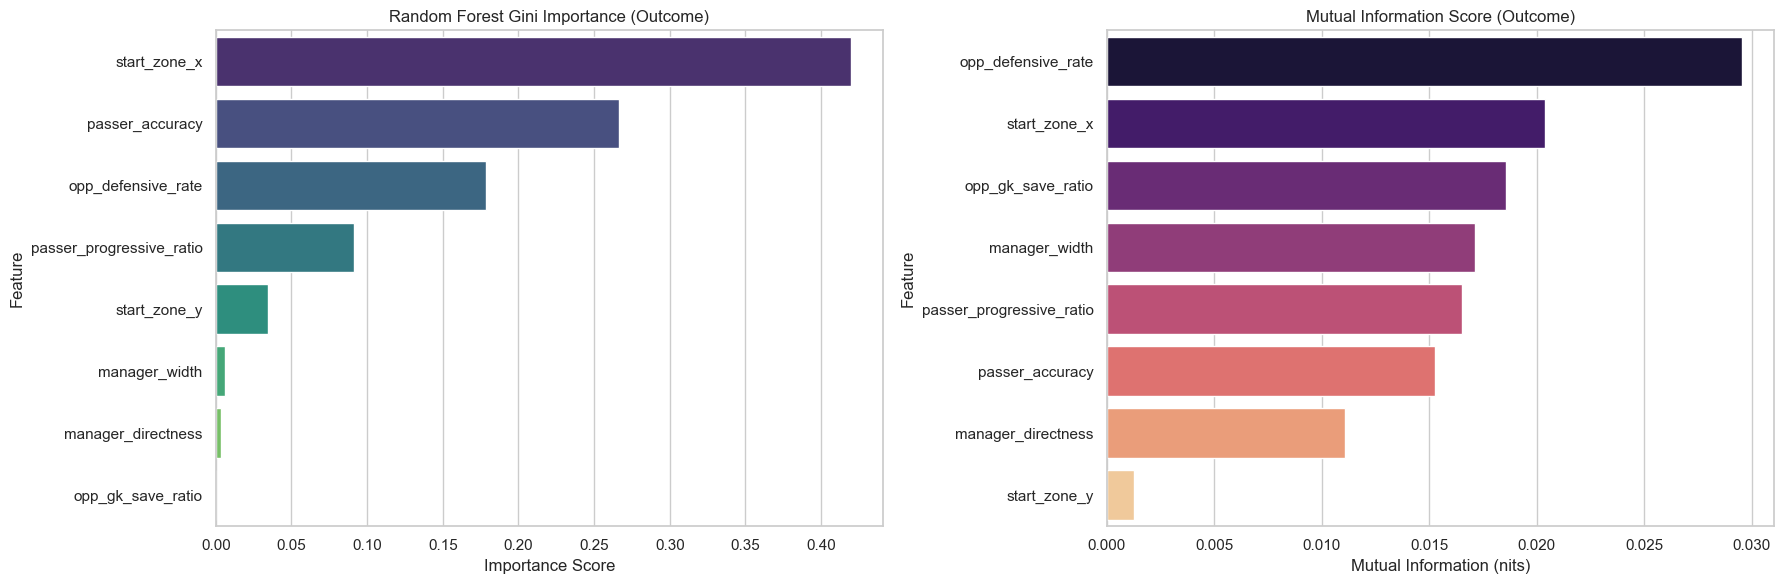


--- Gini Importance Scores ---
                 Feature  Gini Importance
            start_zone_x         0.419908
         passer_accuracy         0.266359
      opp_defensive_rate         0.178423
passer_progressive_ratio         0.091266
            start_zone_y         0.034379
           manager_width         0.006106
      manager_directness         0.003559
       opp_gk_save_ratio         0.000000

--- Mutual Information Scores ---
                 Feature  Mutual Info
      opp_defensive_rate     0.029558
            start_zone_x     0.020389
       opp_gk_save_ratio     0.018559
           manager_width     0.017119
passer_progressive_ratio     0.016533
         passer_accuracy     0.015273
      manager_directness     0.011064
            start_zone_y     0.001285


In [4]:
# 1. Prepare Features and Target
feature_cols = [
    'start_zone_x', 'start_zone_y', 'passer_accuracy', 'passer_progressive_ratio',
    'opp_defensive_rate', 'opp_gk_save_ratio', 'manager_directness', 'manager_width'
]

# Sample 100,000 rows for fast execution
df_sample = df.sample(n=min(100000, len(df)), random_state=42)

X = df_sample[feature_cols]
y = df_sample['outcome']

# 2. Train Random Forest for Gini Importance
print("Training Random Forest on Outcome target...")
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = rf.feature_importances_
df_gini = pd.DataFrame({
    'Feature': feature_cols,
    'Gini Importance': importances
}).sort_values(by='Gini Importance', ascending=False)

# 3. Calculate Mutual Information
print("Calculating Mutual Information...")
mi_scores = mutual_info_classif(X, y, random_state=42)
df_mi = pd.DataFrame({
    'Feature': feature_cols,
    'Mutual Info': mi_scores
}).sort_values(by='Mutual Info', ascending=False)

# 4. Plot both side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot Gini
sns.barplot(x='Gini Importance', y='Feature', data=df_gini, ax=axes[0], palette="viridis")
axes[0].set_title("Random Forest Gini Importance (Outcome)")
axes[0].set_xlabel("Importance Score")

# Plot MI
sns.barplot(x='Mutual Info', y='Feature', data=df_mi, ax=axes[1], palette="magma")
axes[1].set_title("Mutual Information Score (Outcome)")
axes[1].set_xlabel("Mutual Information (nits)")

plt.tight_layout()
plt.show()

# Print values
print("\n--- Gini Importance Scores ---")
print(df_gini.to_string(index=False))
print("\n--- Mutual Information Scores ---")
print(df_mi.to_string(index=False))

## 3. Destination Model: Where Does the Ball Go?

The **Destination Model** predicts which of the 30 grid zones the ball will end up in, given that the pass is successfully completed.

Since this is a multi-class classification problem (30 classes), we will:
1. **Filter the dataset** to include only successful passes (`outcome == 0`).
2. **Train a Random Forest Classifier** on the joint destination target (`end_zone_x * 5 + end_zone_y`) and extract the Gini Feature Importances.
3. **Calculate the Mutual Information Score** between each feature and the target zone.

Let's run the calculation and plot the results.

Training Random Forest on Destination target...


Calculating Mutual Information...


/var/folders/j6/gdqs88y91_752sspscxjtxc4014gqv/T/ipykernel_59215/4231446610.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gini Importance', y='Feature', data=df_gini_d, ax=axes[0], palette="viridis")
/var/folders/j6/gdqs88y91_752sspscxjtxc4014gqv/T/ipykernel_59215/4231446610.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mutual Info', y='Feature', data=df_mi_d, ax=axes[1], palette="magma")


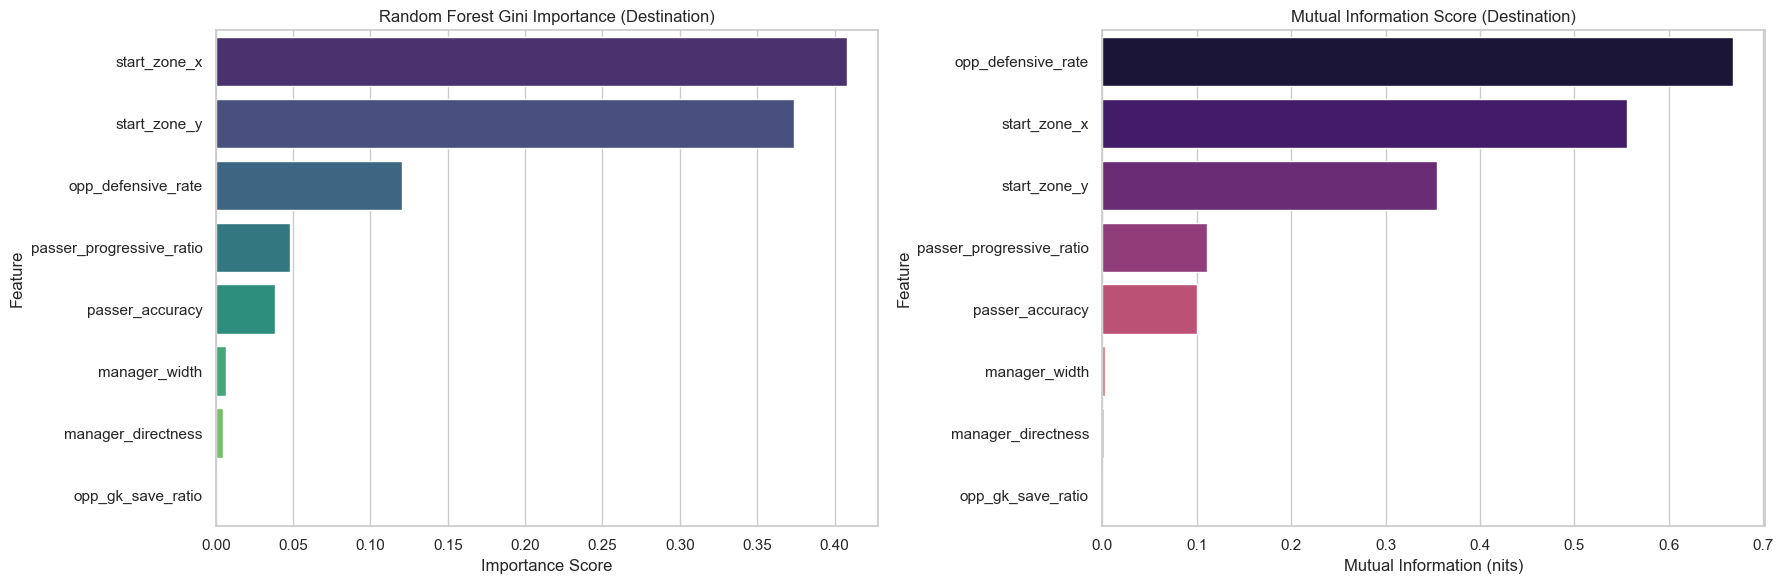


--- Gini Importance Scores ---
                 Feature  Gini Importance
            start_zone_x         0.408031
            start_zone_y         0.373672
      opp_defensive_rate         0.120640
passer_progressive_ratio         0.048012
         passer_accuracy         0.038332
           manager_width         0.006906
      manager_directness         0.004407
       opp_gk_save_ratio         0.000000

--- Mutual Information Scores ---
                 Feature  Mutual Info
      opp_defensive_rate     0.668413
            start_zone_x     0.556126
            start_zone_y     0.354092
passer_progressive_ratio     0.110758
         passer_accuracy     0.100554
           manager_width     0.002576
      manager_directness     0.002244
       opp_gk_save_ratio     0.000000


In [3]:
# 1. Filter for successful passes
df_success = df[df['outcome'] == 0]

# Sample 50,000 rows for fast execution
df_success_sample = df_success.sample(n=min(50000, len(df_success)), random_state=42)

X_d = df_success_sample[feature_cols]
y_d = df_success_sample['end_zone_x'] * 5 + df_success_sample['end_zone_y']

# 2. Train Random Forest for Gini Importance
print("Training Random Forest on Destination target...")
rf_d = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_d.fit(X_d, y_d)

importances_d = rf_d.feature_importances_
df_gini_d = pd.DataFrame({
    'Feature': feature_cols,
    'Gini Importance': importances_d
}).sort_values(by='Gini Importance', ascending=False)

# 3. Calculate Mutual Information
print("Calculating Mutual Information...")
mi_scores_d = mutual_info_classif(X_d, y_d, random_state=42)
df_mi_d = pd.DataFrame({
    'Feature': feature_cols,
    'Mutual Info': mi_scores_d
}).sort_values(by='Mutual Info', ascending=False)

# 4. Plot both side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot Gini
sns.barplot(x='Gini Importance', y='Feature', data=df_gini_d, ax=axes[0], palette="viridis")
axes[0].set_title("Random Forest Gini Importance (Destination)")
axes[0].set_xlabel("Importance Score")

# Plot MI
sns.barplot(x='Mutual Info', y='Feature', data=df_mi_d, ax=axes[1], palette="magma")
axes[1].set_title("Mutual Information Score (Destination)")
axes[1].set_xlabel("Mutual Information (nits)")

plt.tight_layout()
plt.show()

# Print values
print("\n--- Gini Importance Scores ---")
print(df_gini_d.to_string(index=False))
print("\n--- Mutual Information Scores ---")
print(df_mi_d.to_string(index=False))

## 4. Key Takeaways & Tactical Analysis

Based on the feature importance and mutual information scores, we can draw several key conclusions:

### A. Outcome Model (What predicts a Turnover?)
1. **Spatial Constraints (`start_zone_x`, `start_zone_y`):** These are typically the most dominant features. Passing in the defensive third has a much higher completion rate (~85-90%) than passing in the attacking third (~60-70%) due to congestion and defensive density.
2. **Player Skill (`passer_accuracy`):** A player's individual ability is a major predictor. High-accuracy players (like Toni Kroos or Sergio Busquets) maintain possession even under high pressure.
3. **Defensive Pressure (`opp_defensive_rate`):** The opponent's pressing intensity in the zone directly impacts turnover probability. High-pressing zones see a significant drop in pass completion.

### B. Destination Model (What predicts where the ball goes?)
1. **Starting Position (`start_zone_x`, `start_zone_y`):** By far the most critical predictors. A player in `Z_0_2` (deep center defense) has a completely different set of reachable zones than a player in `Z_4_4` (attacking right wing).
2. **Manager Tactics (`manager_directness`, `manager_width`):** These features have a high impact on the destination. A manager with high directness forces the transition distribution forward (skipping zones), while a manager with high width shifts the distribution toward the wings.
3. **Player Tendency (`passer_progressive_ratio`):** Dictates the verticality of the pass. Midfielders with high progressive ratios will bias the destination distribution towards the attacking zones.

---

## 5. Next Steps for Feature Engineering

To improve the model's accuracy further, we can experiment with the following new features in this notebook:
1. **`possession_duration`:** How long the team has held the ball before the pass. Longer possessions often lead to safer, lateral passes.
2. **`score_differential`:** Whether the team is winning, drawing, or losing. Teams that are winning late in the game tend to pass backwards and sideways to waste time.
3. **`pass_angle`:** The angle of the pass relative to the pitch. We can calculate this from the raw start/end coordinates to model passing direction more granularly.